# Space Weather

Two long, freely-available records:

- **SILSO daily sunspot numbers** (Royal Observatory of Belgium, v2.0 series), 1818–present
- **GFZ Potsdam Kp/ap/Ap + SN + F10.7** (Niemegk Observatory), 1932–present

Run `python fetch_spaceweather.py` first to populate `spaceweather.sqlite`.
This notebook reads from there and writes its plots to `figures/`.

In [1]:
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DB = Path("spaceweather.sqlite")
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

conn = sqlite3.connect(DB)

silso = pd.read_sql_query(
    "SELECT date_iso AS date, sunspot_number, n_obs "
    "FROM silso_daily WHERE sunspot_number >= 0",
    conn, parse_dates=["date"],
).set_index("date")

gfz = pd.read_sql_query(
    "SELECT date_iso AS date, ap_daily, sunspot_number, f107_obs, f107_adj "
    "FROM gfz_daily",
    conn, parse_dates=["date"],
).set_index("date")

print(f"SILSO observation days: {len(silso):,} ({silso.index.min().date()} → {silso.index.max().date()})")
print(f"GFZ daily records:      {len(gfz):,} ({gfz.index.min().date()} → {gfz.index.max().date()})")


SILSO observation days: 72,844 (1818-01-08 → 2026-04-30)
GFZ daily records:      34,462 (1932-01-01 → 2026-05-08)


## 1. Sunspot number, 1818–present

The 11-year solar cycle. Plotting daily values from 1818 makes the pre-1849
data sparsity visible — gappy, low counts not because the Sun was quiet but
because daily global observation hadn't been organized yet.

Smoothed series uses the standard SIDC convention: monthly means, then a
13-month centered running mean.

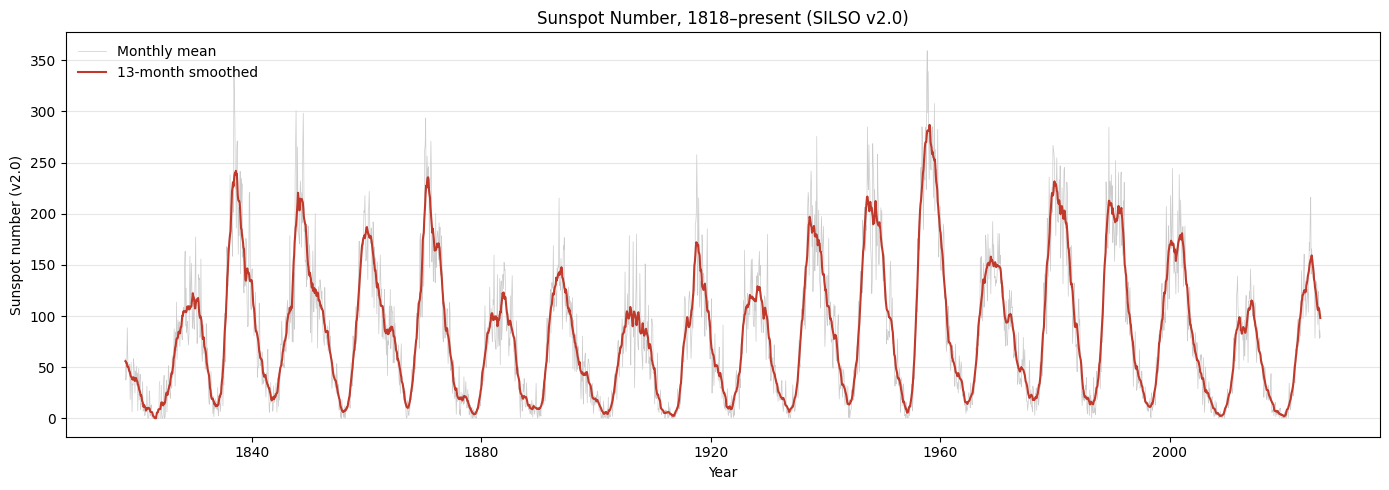

In [2]:
monthly = silso["sunspot_number"].resample("MS").mean()
smooth = monthly.rolling(window=13, center=True, min_periods=7).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly.index, monthly.values, color="#cccccc", lw=0.5, label="Monthly mean")
ax.plot(smooth.index, smooth.values, color="#c0392b", lw=1.5, label="13-month smoothed")
ax.set_ylabel("Sunspot number (v2.0)")
ax.set_xlabel("Year")
ax.set_title("Sunspot Number, 1818–present (SILSO v2.0)")
ax.legend(loc="upper left", frameon=False)
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "01_sunspot_history.png", dpi=140)
plt.show()


## 2. Yearly mean — cycles at a glance

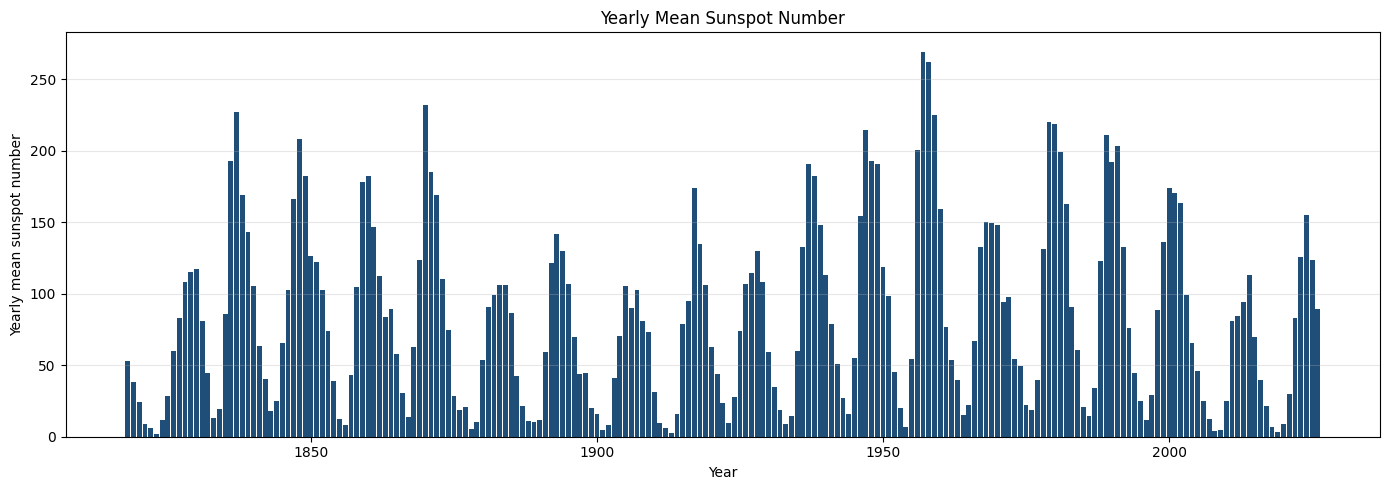

In [3]:
yearly = silso["sunspot_number"].resample("YS").mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(yearly.index.year, yearly.values, color="#1f4e79", width=0.85)
ax.set_ylabel("Yearly mean sunspot number")
ax.set_xlabel("Year")
ax.set_title("Yearly Mean Sunspot Number")
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "02_yearly_sunspots.png", dpi=140)
plt.show()


## 3. Solar cycle peak amplitudes

Cycle start dates are SIDC's official minima. Peak = max of 13-month smoothed
monthly mean within each cycle. Cycle 24 (red) is highlighted because its
weakness was the central debate of the early 2010s — and the v2.0 reboot
in 2015 changed how "weak" it actually looks.

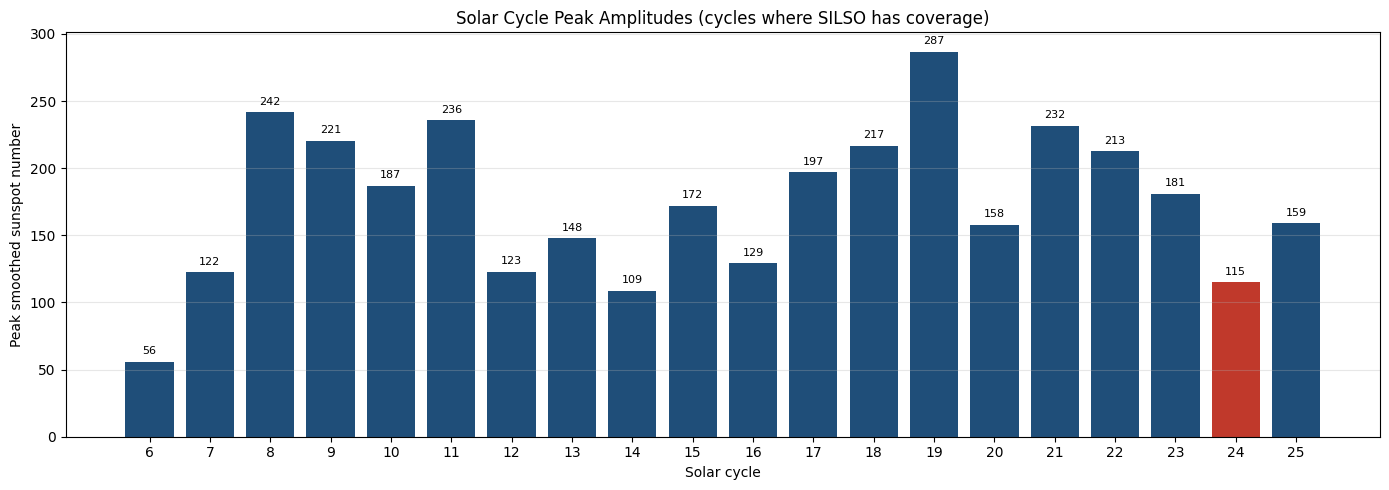

 cycle  peak_date       peak
     6 1818-01-01  55.925204
     7 1829-10-01 122.330499
     8 1837-04-01 241.963129
     9 1848-02-01 220.527458
    10 1860-02-01 186.968469
    11 1870-10-01 235.681951
    12 1883-12-01 123.014115
    13 1894-01-01 147.734509
    14 1906-01-01 108.902275
    15 1917-07-01 172.170980
    16 1928-03-01 129.097675
    17 1937-04-01 197.063724
    18 1947-05-01 216.817317
    19 1958-03-01 286.885744
    20 1968-11-01 158.041126
    21 1979-12-01 231.701888
    22 1989-06-01 212.756995
    23 2002-03-01 180.907781
    24 2014-04-01 115.311202
    25 2024-10-01 159.217890


In [4]:
# Solar cycle minima (start months) per SIDC. Cycle N runs from minimum N to minimum N+1.
cycle_minima = [
    (1, "1755-02"), (2, "1766-06"), (3, "1775-06"), (4, "1784-09"),
    (5, "1798-04"), (6, "1810-07"), (7, "1823-05"), (8, "1833-11"),
    (9, "1843-07"), (10, "1855-12"), (11, "1867-03"), (12, "1878-12"),
    (13, "1890-03"), (14, "1902-01"), (15, "1913-08"), (16, "1923-08"),
    (17, "1933-09"), (18, "1944-02"), (19, "1954-04"), (20, "1964-10"),
    (21, "1976-03"), (22, "1986-09"), (23, "1996-08"), (24, "2008-12"),
    (25, "2019-12"),
]

peaks = []
for i, (num, start_str) in enumerate(cycle_minima):
    start = pd.Timestamp(start_str)
    end = (pd.Timestamp(cycle_minima[i + 1][1])
           if i + 1 < len(cycle_minima) else smooth.index.max())
    seg = smooth.loc[start:end].dropna()
    if seg.empty:
        continue
    peaks.append((num, seg.idxmax(), float(seg.max())))

peak_df = pd.DataFrame(peaks, columns=["cycle", "peak_date", "peak"])

colors = ["#c0392b" if c == 24 else "#1f4e79" for c in peak_df["cycle"]]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(peak_df["cycle"], peak_df["peak"], color=colors)
for _, row in peak_df.iterrows():
    ax.text(row["cycle"], row["peak"] + 4, f"{row['peak']:.0f}",
            ha="center", va="bottom", fontsize=8)
ax.set_xlabel("Solar cycle")
ax.set_ylabel("Peak smoothed sunspot number")
ax.set_title("Solar Cycle Peak Amplitudes (cycles where SILSO has coverage)")
ax.set_xticks(peak_df["cycle"])
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "03_cycle_peaks.png", dpi=140)
plt.show()

print(peak_df.to_string(index=False))


## 4. Geomagnetic storm days per year — the detection-bias control

Sunspot counting is sensitive to who's counting and how. The Kp/ap network is
sensitive to the planet's magnetic field at fixed observatory locations and
has been calibrated consistently since 1932. If solar activity is genuinely
trending, it should show in storm-day counts too.

The Ap thresholds correspond loosely to NOAA's G-scale:
- Ap ≥ 30: at least one Kp~5 (G1 minor) interval
- Ap ≥ 50: at least one Kp~6 (G2 moderate) interval
- Ap ≥ 100: severe (G3+) day

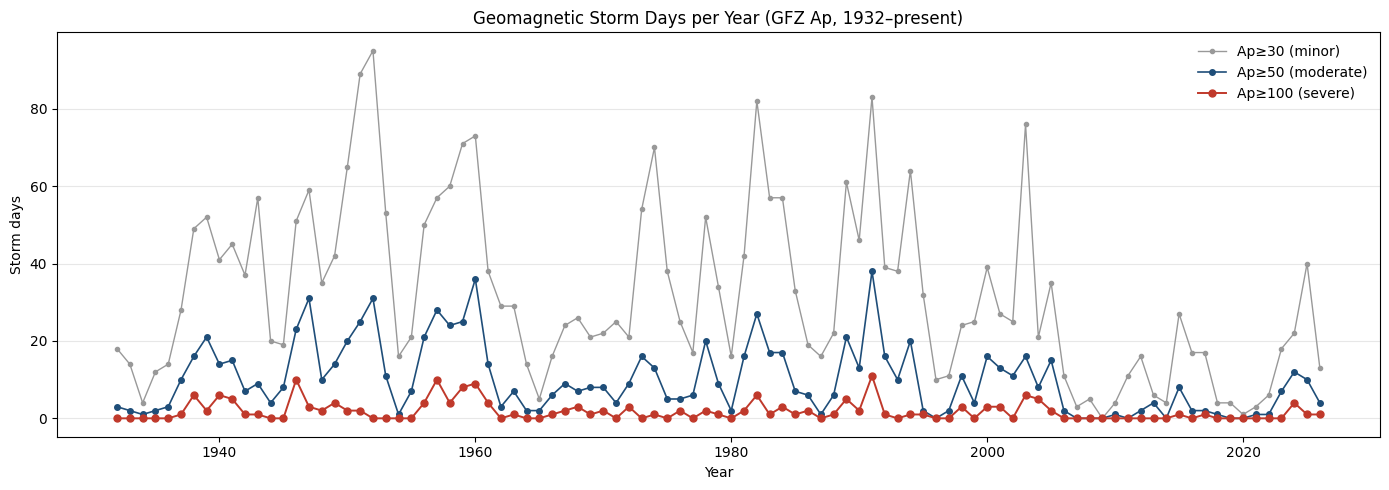

In [5]:
g = gfz[gfz["ap_daily"] >= 0].copy()
g["minor"] = g["ap_daily"] >= 30
g["moderate"] = g["ap_daily"] >= 50
g["strong"] = g["ap_daily"] >= 100

storms = g.groupby(g.index.year)[["minor", "moderate", "strong"]].sum()
storms.index.name = "year"

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(storms.index, storms["minor"],    "o-", color="#999999", lw=1.0, ms=3, label="Ap≥30 (minor)")
ax.plot(storms.index, storms["moderate"], "o-", color="#1f4e79", lw=1.2, ms=4, label="Ap≥50 (moderate)")
ax.plot(storms.index, storms["strong"],   "o-", color="#c0392b", lw=1.4, ms=5, label="Ap≥100 (severe)")
ax.set_xlabel("Year")
ax.set_ylabel("Storm days")
ax.set_title("Geomagnetic Storm Days per Year (GFZ Ap, 1932–present)")
ax.legend(loc="upper right", frameon=False)
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "04_storm_days.png", dpi=140)
plt.show()


## 5. F10.7 cm radio flux vs sunspot number

F10.7 is measured by a single instrument (Penticton, BC) and isn't subject to
the visual-observer bias that affects historical sunspot counts. Their
correlation since 1947 is the cleanest available cross-check that the v2.0
sunspot series is measuring the same underlying solar activity that the radio
flux is.

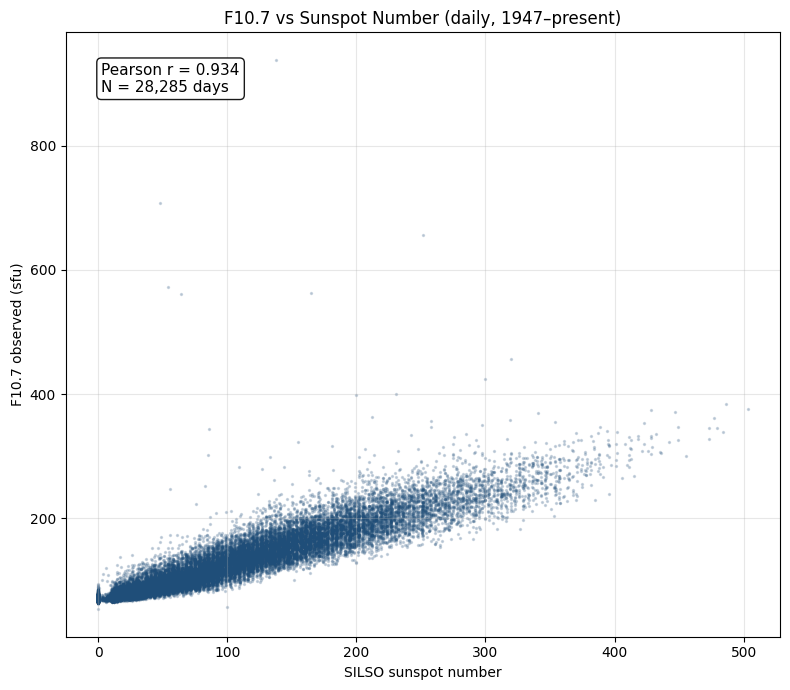

In [6]:
xcheck = gfz[(gfz["f107_obs"] > 0) & (gfz["sunspot_number"] >= 0)]

r = xcheck[["sunspot_number", "f107_obs"]].corr().iloc[0, 1]

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(xcheck["sunspot_number"], xcheck["f107_obs"],
           s=2, alpha=0.2, color="#1f4e79")
ax.set_xlabel("SILSO sunspot number")
ax.set_ylabel("F10.7 observed (sfu)")
ax.set_title("F10.7 vs Sunspot Number (daily, 1947–present)")
ax.grid(True, alpha=0.3)
ax.text(0.05, 0.95, f"Pearson r = {r:.3f}\nN = {len(xcheck):,} days",
        transform=ax.transAxes, va="top", fontsize=11,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.9))
fig.tight_layout()
fig.savefig(FIG_DIR / "05_f107_vs_sunspot.png", dpi=140)
plt.show()


---

That's the baseline. Open questions worth following up on in this notebook:

- Is the apparent decline in sunspot peaks since Cycle 19 real, or an artifact
  of the v2.0 recalibration?
- Has the storm-day rate genuinely tracked the sunspot cycle, or is there a
  secular trend in the geomagnetic record that solar indices alone don't see?
- The pre-1849 SILSO data is sparse — what does it look like if you require
  `n_obs >= 1` per day and re-aggregate?